In [5]:
import os as os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from scipy.signal import get_window
from gwpy.timeseries import TimeSeriesDict
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)


from psd_estimation_methods.wosa import wosa
from psd_estimation_methods.lpsd import lpsd, lpsd_wosa
from psd_estimation_methods.logpsd import logpsd
from scripts.plot import plot, plot_segments
from scripts.readTdi import readTdi, getTdiPath
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
plt.rcParams['text.usetex'] = False


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

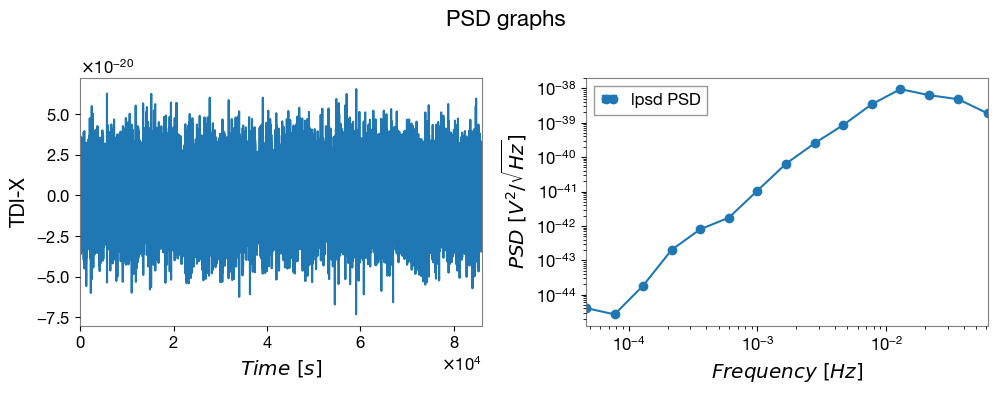

In [6]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig_logpsd, psd_orig_logpsd, _ = logpsd(
    x=data_orig, 
    fs=fs, 
    overlap=0, 
    L1=17200
)

f_median, psd_median, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

plot(
    data=data_orig,
    t=t, 
    f=f_orig_logpsd, 
    psd= [psd_orig_logpsd],
    labels= ["lpsd PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_logpsd[0], f_orig_logpsd[-1]],
    logpsd=True
)

psd_median = [7.97520349e-39 7.78689228e-39 1.01735287e-38 6.64586865e-39
 7.79215954e-39 8.08774505e-39 4.66826124e-39 4.14470501e-39
 7.59742185e-39 5.27720131e-39 7.87058468e-39 5.99997039e-39
 9.77462710e-39 1.40411480e-38 8.68047057e-39 5.19077873e-39
 4.38001547e-39 6.26168334e-39 7.20997738e-39 4.46757475e-39]
psd_out = [9.17153391e-39 8.97424707e-39 1.07506789e-38 6.13306257e-39
 7.51376130e-39 8.11862521e-39 5.99396052e-39 5.80520024e-39
 7.28047343e-39 5.85086720e-39 7.31796739e-39 7.30032897e-39
 1.05179235e-38 1.20326657e-38 8.62216024e-39 6.40659010e-39
 5.23342942e-39 7.05839328e-39 8.44246889e-39 7.65011433e-39]
Number of segments = 16


/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


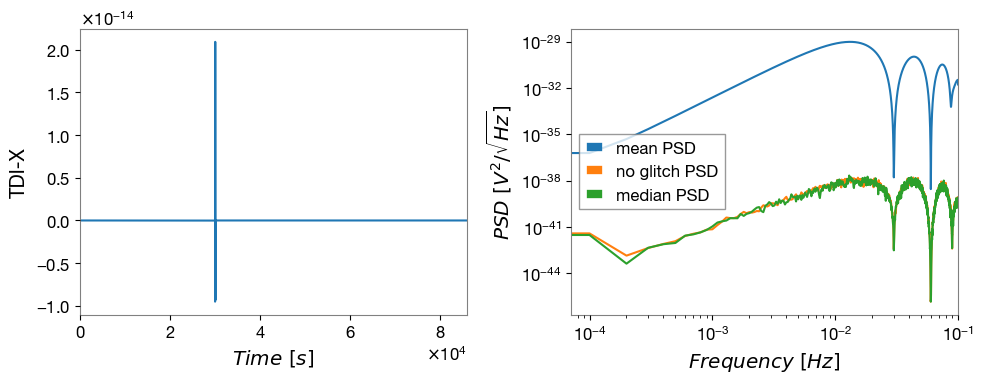

In [7]:
# list of your four datasets
file_list = [
    'glitch_9_one_day.h5'
]

nperseg = 2000

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

   
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )
    print(f"psd_median = {psd_median[200: 220]}")
    print(f"psd_out = {psd_out[200: 220]}")

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[
            psd_mean, 
            psd_orig ,
            psd_median, 
            # psd_out
        ],
        labels=[
            "mean PSD", 
            "no glitch PSD" , 
            "median PSD", 
            # "outlier"
        ],
        title=f"TDI-X",
        f_lims=[f_mean[0], f_mean[-1]]
    )

print(f"Number of segments = {nseg[0]}")

Number of segments = 8


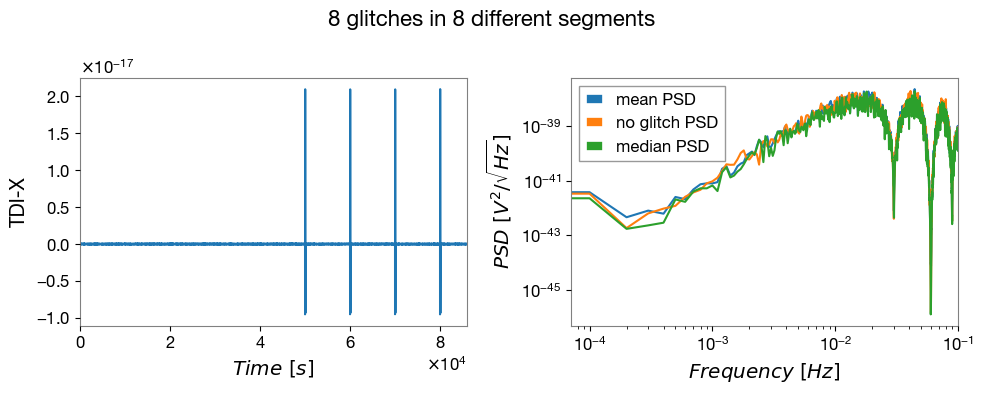

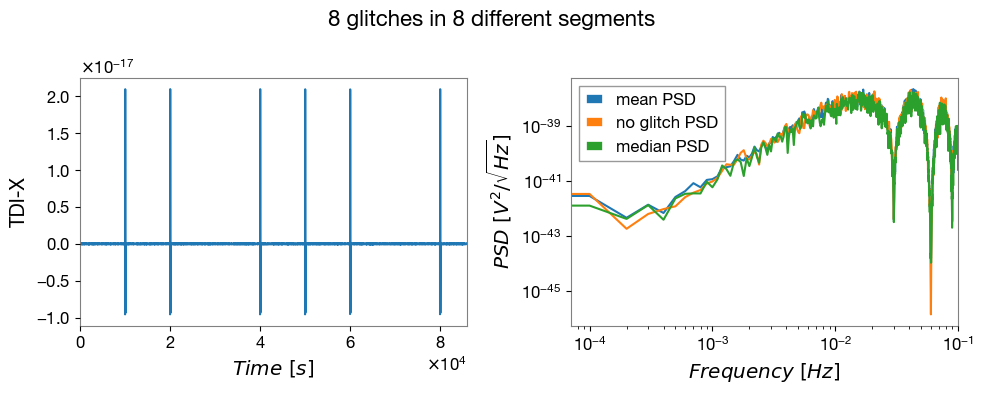

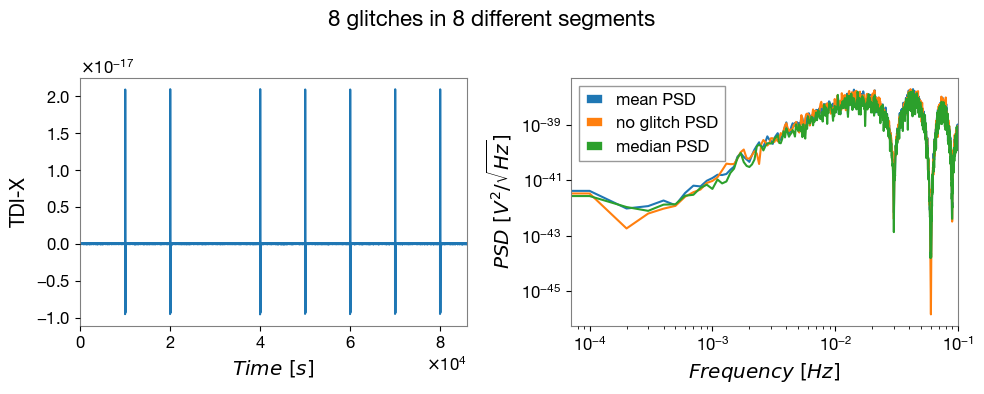

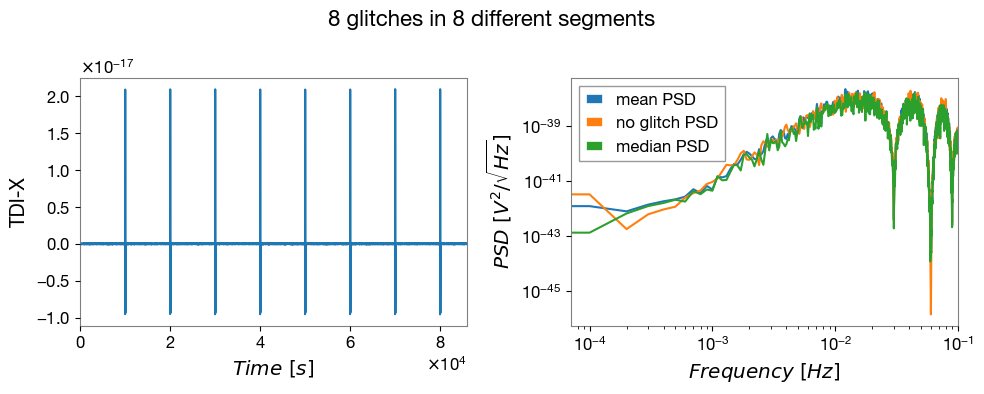

In [8]:
# list of your four datasets
file_list = [
    'glitch_7_multiple_3.h5',
    'glitch_7_multiple_4.h5',
    'glitch_7_multiple_5.h5',
    'glitch_7_multiple_2.h5'
]

nperseg = 2000
noverlap= 0

# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean",
    noverlap=noverlap
) 

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean",
        noverlap=noverlap
    )

   
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median",
        noverlap=noverlap
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection",
        noverlap=noverlap
    )
    # print(f_mean.size)
    # print(psd_mean.size)
    # print(psd_median.size)
    # print(psd_mean.size)

    # print(f"psd_median = {psd_median[200: 220]}")
    # print(f"psd_out = {psd_out[200: 220]}")

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[
            psd_mean, 
            psd_orig ,
            psd_median, 
            # psd_out
        ],
        labels=[
            "mean PSD", 
            "no glitch PSD" , 
            "median PSD", 
            # "outlier"
        ],
        title=f"TDI-X",
        f_lims=[f_mean[0], f_mean[-1]],
        bigtitle="8 glitches in 8 different segments"
    )

print(f"Number of segments = {nseg[0]}")

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

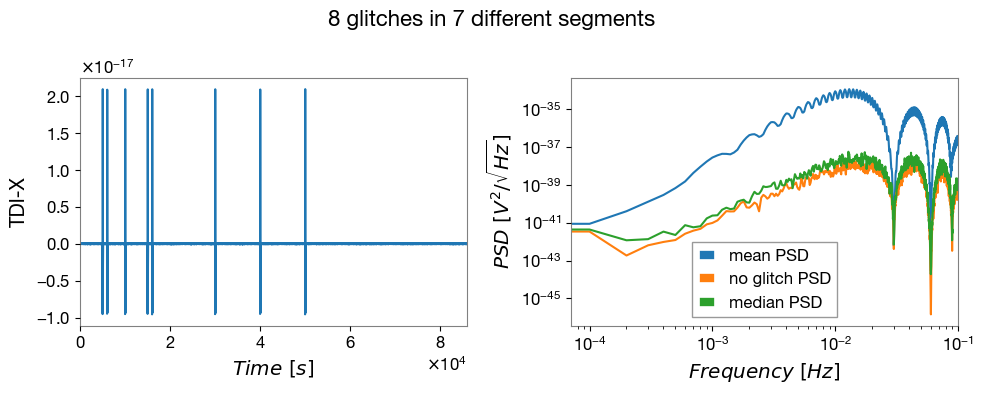

In [9]:
tdi_path = getTdiPath('glitch_7_multiple_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig, psd_median],
    labels= ["mean PSD", "no glitch PSD", "median PSD"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]],
    bigtitle="8 glitches in 7 different segments"
)



Number of segments = 21


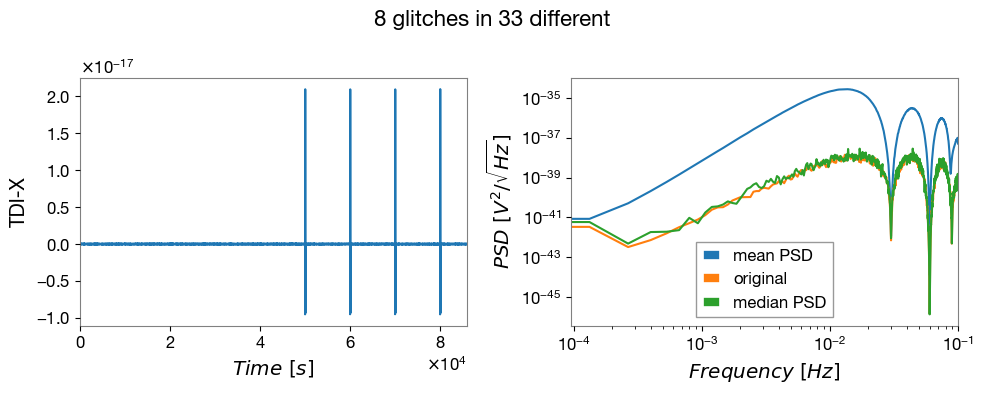

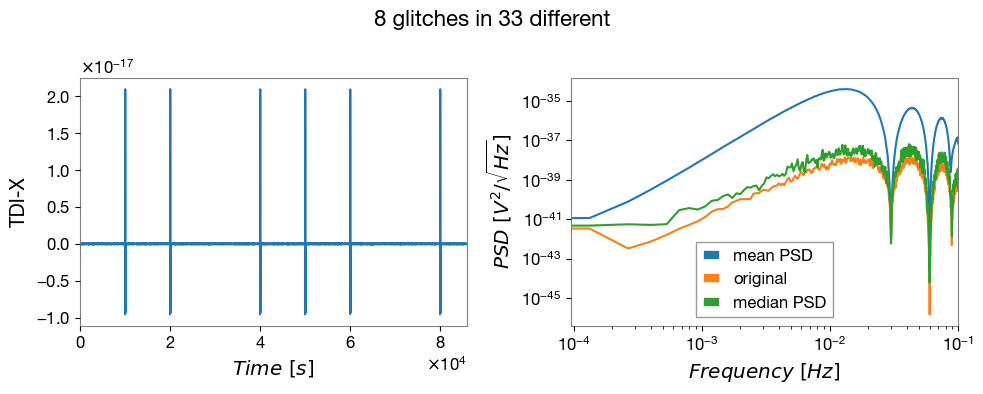

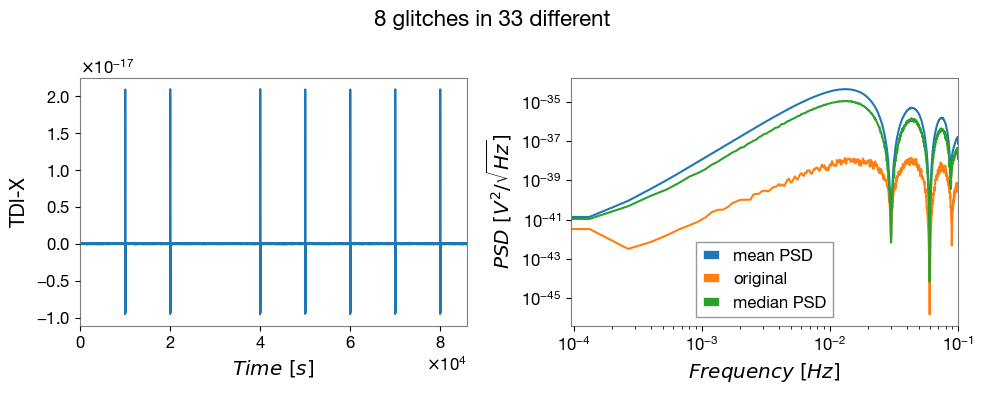

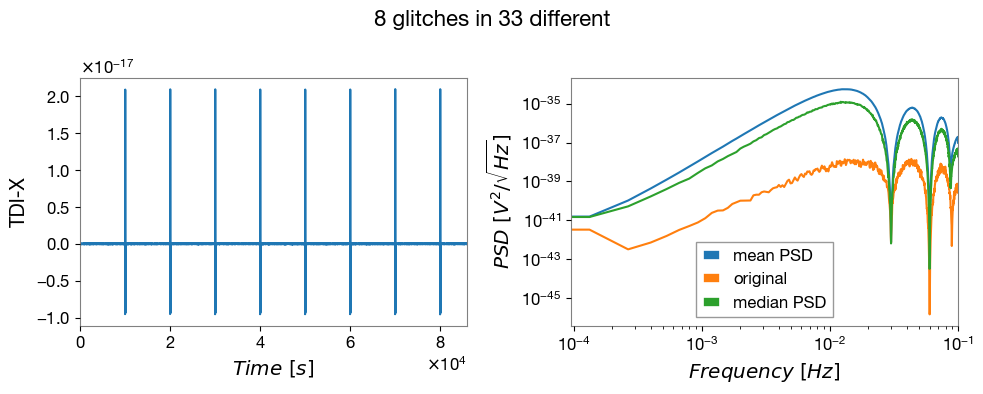

In [10]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 1500
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

# list of your four datasets
file_list = [
    'glitch_7_multiple_3.h5',
    'glitch_7_multiple_4.h5',
    'glitch_7_multiple_5.h5',
    'glitch_7_multiple_2.h5'
]

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    # compute mean‐PSD (and print # segments)
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

    # compute median‐PSD
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[
            psd_mean,
            psd_orig,
            psd_median,  
            # psd_out
        ],
        labels=[
            "mean PSD",
            "original", 
            "median PSD", 
            # "outlier"
        ],
        #title=f"TDI-X ({fname})",
        title=f"TDI-X",
        f_lims=[f_mean[0], f_mean[-1]],
        bigtitle="8 glitches in 33 different"
    )

print(f"Number of segments = {nseg[0]}")

ValueError: x and y must have same first dimension, but have shapes (1001,) and (751,)

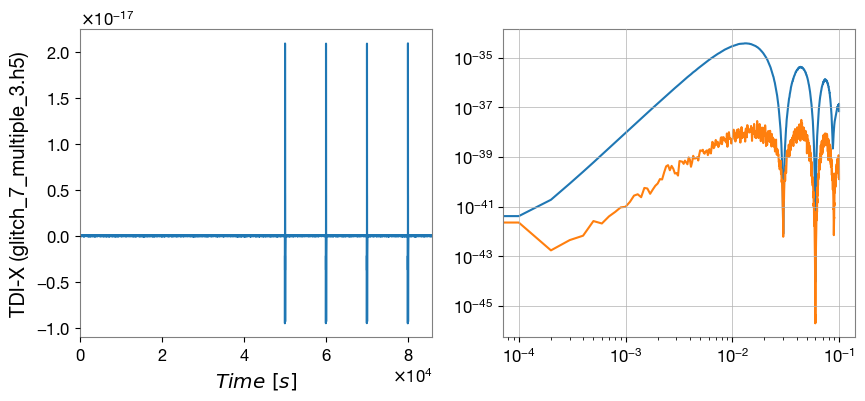

In [11]:
# list of your four datasets
file_list = [
    'glitch_7_multiple_3.h5',
    'glitch_7_multiple_4.h5',
    'glitch_7_multiple_5.h5',
    'glitch_7_multiple_2.h5'
]

nperseg = 2000

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    # compute mean‐PSD (and print # segments)
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

    # compute median‐PSD
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[psd_mean, psd_median, psd_orig, psd_out],
        labels=["mean PSD", "median PSD", "original", "outlier"],
        title=f"TDI-X ({fname})",
        f_lims=[f_mean[0], f_mean[-1]]
    )

print(f"Number of segments = {nseg[0]}")

psd_median = [7.97520349e-39 7.78689228e-39 1.01735287e-38 6.64586865e-39
 7.79215954e-39 8.08774505e-39 4.66826124e-39 4.14470501e-39
 7.59742185e-39 5.27720131e-39 7.87058468e-39 5.99997039e-39
 9.77462710e-39 1.40411480e-38 8.68047057e-39 5.19077873e-39
 4.38001547e-39 6.26168334e-39 7.20997738e-39 4.46757475e-39]
psd_out = [9.17153391e-39 8.97424707e-39 1.07506789e-38 6.13306257e-39
 7.51376130e-39 8.11862521e-39 5.99396052e-39 5.80520024e-39
 7.28047343e-39 5.85086720e-39 7.31796739e-39 7.30032897e-39
 1.05179235e-38 1.20326657e-38 8.62216024e-39 6.40659010e-39
 5.23342942e-39 7.05839328e-39 8.44246889e-39 7.65011433e-39]


ValueError: x and y must have same first dimension, but have shapes (1001,) and (751,)

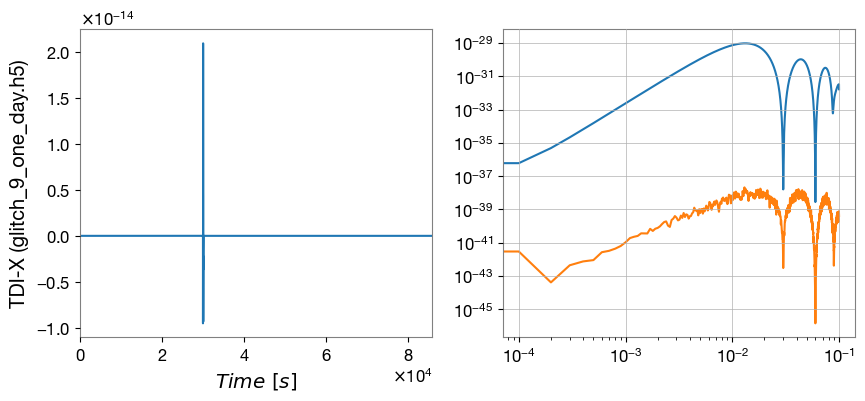

In [12]:
# list of your four datasets
file_list = [
    'glitch_9_one_day.h5'
]

nperseg = 2000

for fname in file_list:
    # load
    tdi_path = getTdiPath(fname)
    data, fs, t = readTdi(tdi_path)

    # if you need idx again
    delta_t = 1 / fs
    idx     = nperseg / delta_t

    # compute mean‐PSD (and print # segments)
    f_mean, psd_mean, _, nseg = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="mean"
    )

    # compute median‐PSD
    f_median, psd_median, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="median"
    )

    f_out, psd_out, _, _ = wosa(
        x=data,
        fs=fs,
        nperseg=nperseg,
        method="outlier_rejection"
    )
    print(f"psd_median = {psd_median[200: 220]}")
    print(f"psd_out = {psd_out[200: 220]}")

    # plot all three curves (assuming psd_orig is defined)
    plot(
        data=data,
        t=t,
        f=f_mean,
        psd=[psd_mean, psd_median, psd_orig, psd_out],
        labels=["mean PSD", "median PSD", "original", "outlier"],
        title=f"TDI-X ({fname})",
        f_lims=[f_mean[0], f_mean[-1]]
    )

print(f"Number of segments = {nseg[0]}")

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

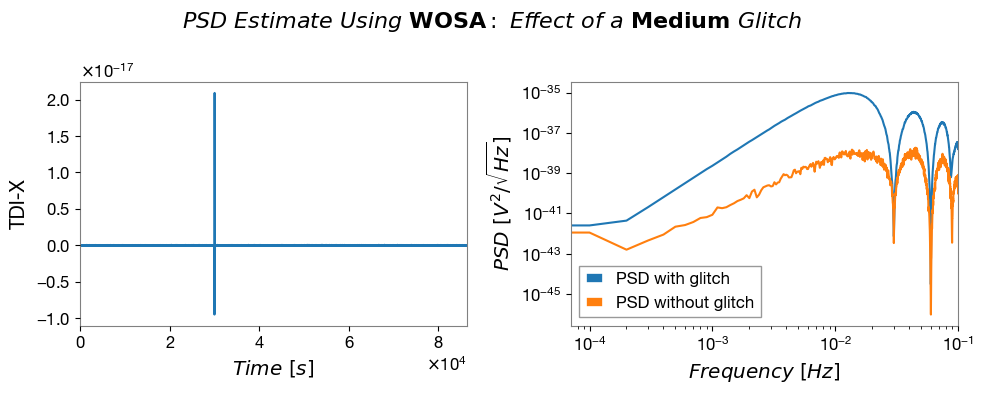

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    f_lims = [f_mean[0], f_mean[-1]],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

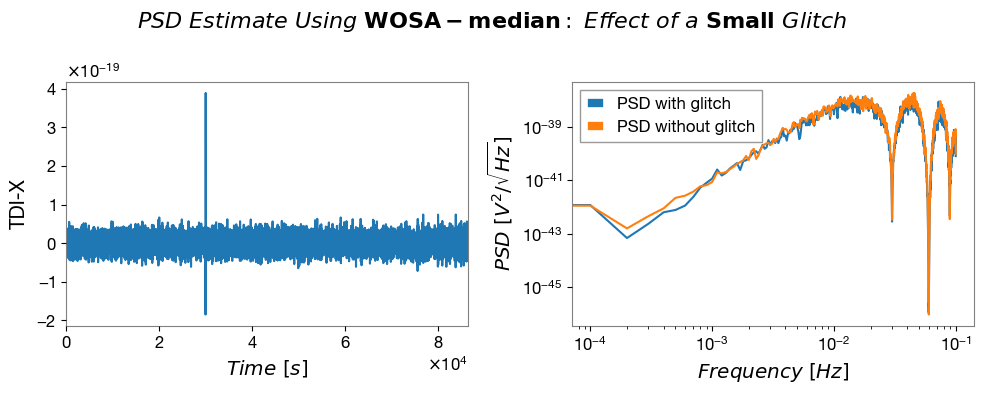

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_median, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA-median}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

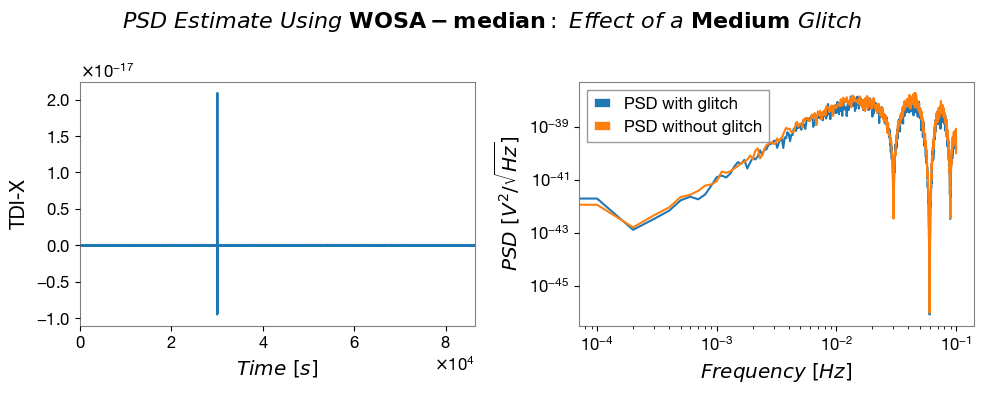

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_median, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA-median}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$",
)

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

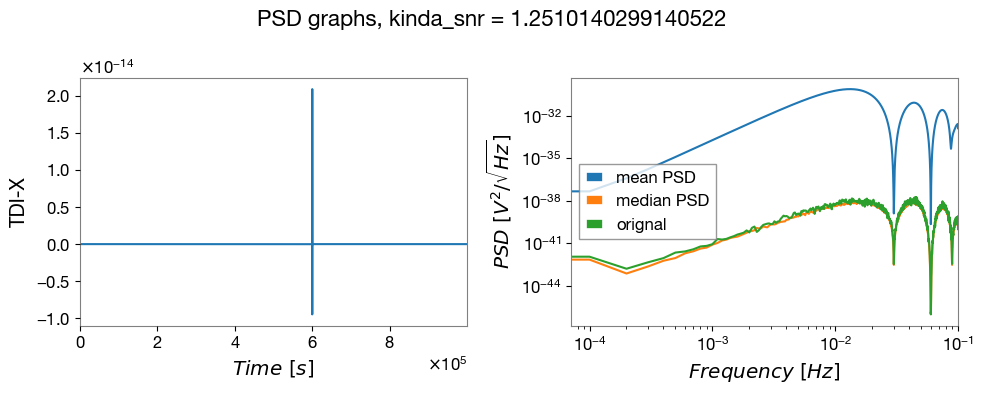

In [ ]:
tdi_path = getTdiPath('glitch_9.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

In [ ]:
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

tdi_path = getTdiPath('glitch_9.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["mean PSD", "no glitch"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)

NameError: name 'wosa' is not defined

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

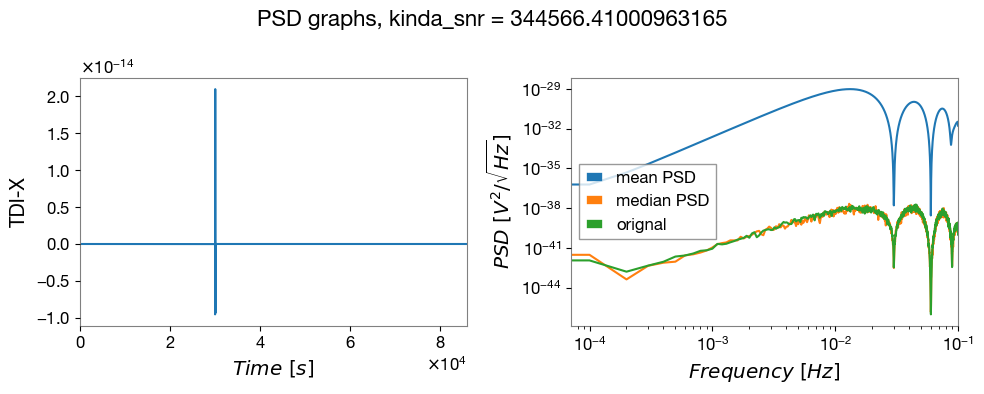

In [ ]:
tdi_path = getTdiPath('glitch_9_one_day.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

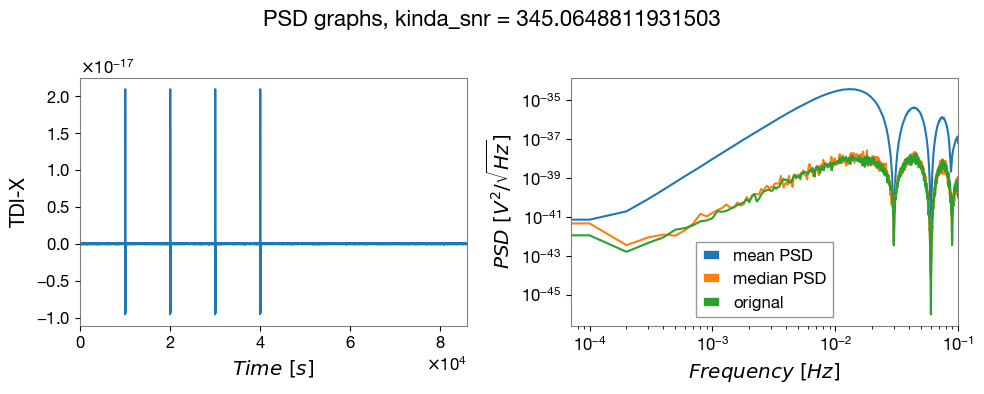

In [ ]:
tdi_path = getTdiPath('glitch_7_multiple.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

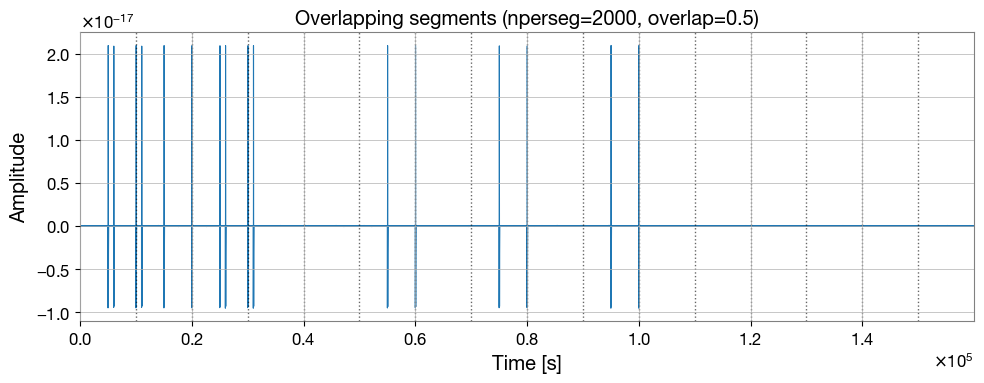

In [ ]:
tdi_path = getTdiPath('glitch_7_multiple_7.h5')
data, fs, t = readTdi(tdi_path)
fig, ax = plot_segments(data, nperseg=2000, overlap=0.5, t=t, fs=fs)
plt.show()

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


Number of segments = 16


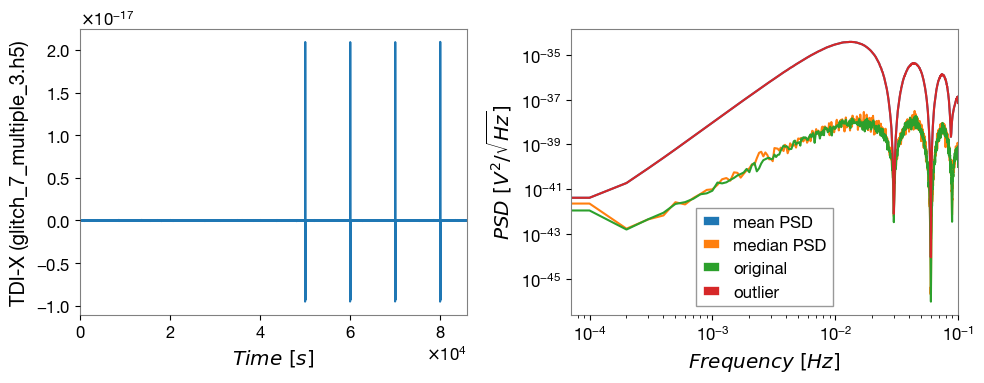

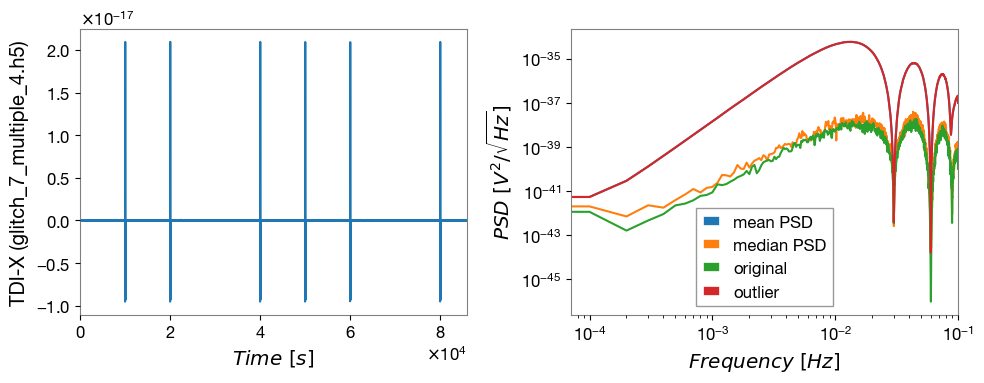

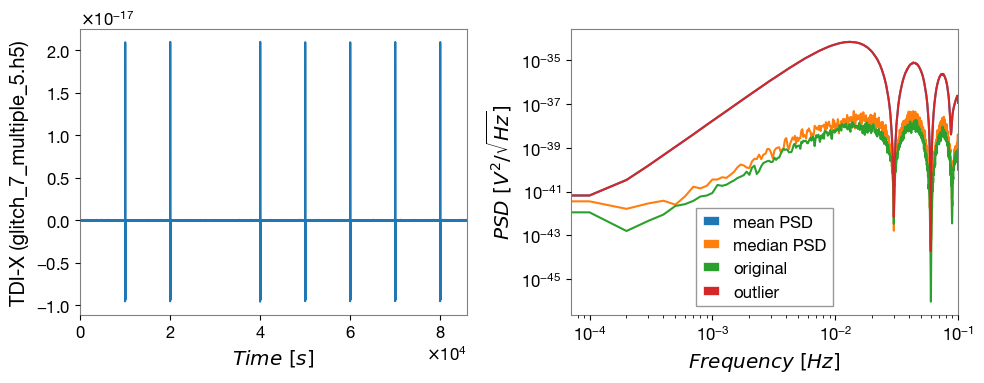

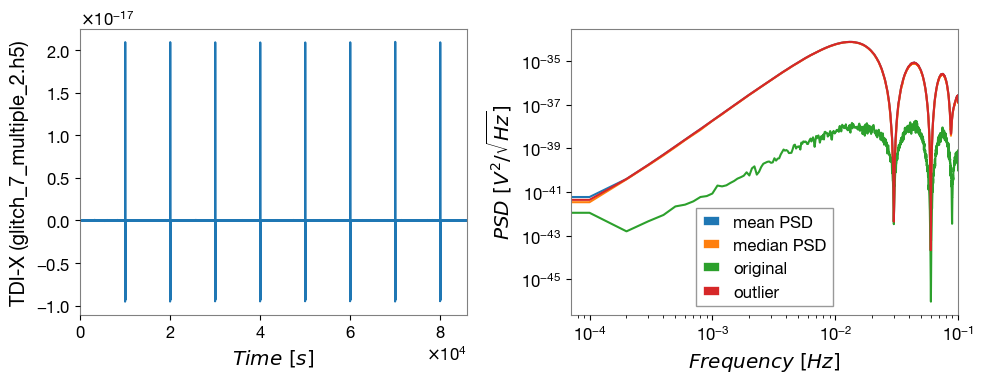